In [ ]:
import threading
import queue
import time

# --- STAGE 2 CONFIG: State Bridge with capacity exactly = 1 ---
state_bridge = queue.Queue(maxsize=1)
stop_signal = threading.Event()

# Storage arrays for STAGE 3 telemetry plotting
production_timestamps = []
consumption_timestamps = []
packet_ids_produced = []
packet_ids_consumed = []

def vlm_producer():
    """
    PRODUCER: Simulates the Vision-Language Model generating spatial
    targets slowly every 0.5 seconds.
    """
    print(f"[{threading.current_thread().name}] VLM Command Engine started (0.5s interval).")
    command_id = 1

    while not stop_signal.is_set():
        timestamp = time.time()  # Capture exact generation time
        command_packet = {"id": command_id, "timestamp": timestamp}

        # Overwrite logic: if the slot is full, pull the old out to put the newest in
        if state_bridge.full():
            try:
                state_bridge.get_nowait()
                state_bridge.task_done()
            except queue.Empty:
                pass

        try:
            state_bridge.put(command_packet, block=False)
            production_timestamps.append(timestamp)
            packet_ids_produced.append(command_id)
            print(f"[{threading.current_thread().name}] Generated Command #{command_id} at {time.strftime('%H:%M:%S', time.localtime(timestamp))}")
        except queue.Full:
            pass

        command_id += 1
        time.sleep(0.5)  # 0.5-second delay

    print(f"[{threading.current_thread().name}] VLM Engine safely parked.")


def ik_consumer():
    """
    CONSUMER: Simulates the Inverse Kinematics loop polling the
    middleware register at a blazing fast 100Hz (every 0.01s).
    """
    print(f"[{threading.current_thread().name}] IK Motor Loop active polling at 100Hz.")

    while not stop_signal.is_set() or not state_bridge.empty():
        try:
            # Non-blocking check for commands
            command_packet = state_bridge.get_nowait()
            consume_time = time.time()

            # Log telemetry for latency analysis
            consumption_timestamps.append(consume_time)
            packet_ids_consumed.append(command_packet["id"])

            latency = consume_time - command_packet["timestamp"]
            print(f"    🌟 [{threading.current_thread().name}] Executing Command #{command_packet['id']} | Latency: {latency:.4f}s")

            state_bridge.task_done()

        except queue.Empty:
            # At 100Hz, the queue will often be empty.
            # We sleep for 0.01s (100Hz) and poll again instantly.
            time.sleep(0.01)

    print(f"[{threading.current_thread().name}] IK Loop safely parked.")

# --- Start Simulation ---
print("[Main] Launching ADCA Middleware Synchronization Interface...")
vlm_thread = threading.Thread(target=vlm_producer, name="VLM_Producer")
ik_thread = threading.Thread(target=ik_consumer, name="IK_Consumer")

vlm_thread.start()
ik_thread.start()

# Let data exchange cycle for 3.0 seconds live
time.sleep(3.0)

print("\n[Main] Stopping simulation timeline...")
stop_signal.set()

vlm_thread.join()
ik_thread.join()

print("[Main] Engine simulation complete. Telemetry buffers compiled.")

[Main] Launching ADCA Middleware Synchronization Interface...
[VLM_Producer] VLM Command Engine started (0.5s interval).
[VLM_Producer] Generated Command #1 at 07:34:53
[IK_Consumer] IK Motor Loop active polling at 100Hz.
    🌟 [IK_Consumer] Executing Command #1 | Latency: 0.0007s
[VLM_Producer] Generated Command #2 at 07:34:53
    🌟 [IK_Consumer] Executing Command #2 | Latency: 0.0085s
[VLM_Producer] Generated Command #3 at 07:34:54
    🌟 [IK_Consumer] Executing Command #3 | Latency: 0.0065s
[VLM_Producer] Generated Command #4 at 07:34:54
    🌟 [IK_Consumer] Executing Command #4 | Latency: 0.0048s
[VLM_Producer] Generated Command #5 at 07:34:55
    🌟 [IK_Consumer] Executing Command #5 | Latency: 0.0033s
[VLM_Producer] Generated Command #6 at 07:34:55
    🌟 [IK_Consumer] Executing Command #6 | Latency: 0.0015s

[Main] Stopping simulation timeline...
[IK_Consumer] IK Loop safely parked.
[VLM_Producer] VLM Engine safely parked.
[Main] Engine simulation complete. Telemetry buffers compile

##**command generation timestamps vs. consumption timestamps**

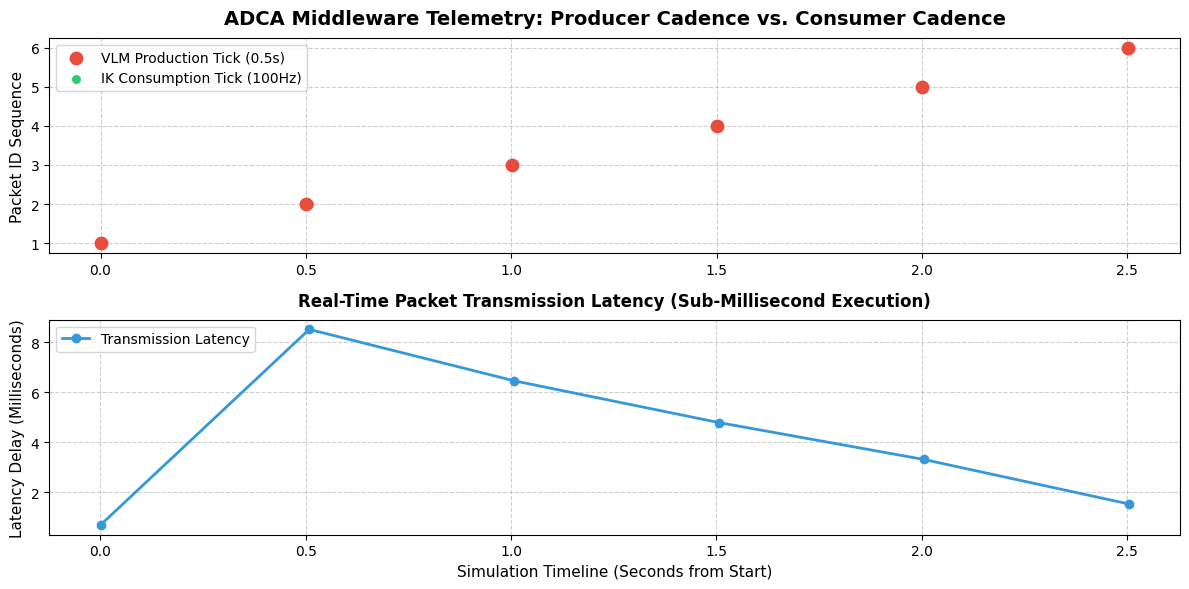

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate the exact processing latency for each consumed packet
# We match the consumption time against the production time stored inside the packet tracking data
latencies = [c - p for c, p in zip(consumption_timestamps, production_timestamps)]

# 2. Convert raw epoch timestamps into relative simulation time (seconds from start)
start_time = production_timestamps[0]
relative_prod_time = [p - start_time for p in production_timestamps]
relative_cons_time = [c - start_time for c in consumption_timestamps]

# 3. Create the multi-panel visualization figure
plt.figure(figsize=(12, 6))

# --- UPPER SUBPLOT: Cadence Comparison timeline ---
plt.subplot(2, 1, 1)
plt.scatter(relative_prod_time, packet_ids_produced, color='#e74c3c', label='VLM Production Tick (0.5s)', zorder=3, s=80)
plt.scatter(relative_cons_time, packet_ids_consumed, color='#2ecc71', label='IK Consumption Tick (100Hz)', zorder=2, s=30)
plt.title('ADCA Middleware Telemetry: Producer Cadence vs. Consumer Cadence', fontsize=14, fontweight='bold', pad=10)
plt.ylabel('Packet ID Sequence', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')

# --- LOWER SUBPLOT: Real-Time Transmission Latency ---
plt.subplot(2, 1, 2)
plt.plot(relative_cons_time, np.array(latencies) * 1000, color='#3498db', linestyle='-', marker='o', linewidth=2, label='Transmission Latency')
plt.title('Real-Time Packet Transmission Latency (Sub-Millisecond Execution)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Simulation Timeline (Seconds from Start)', fontsize=11)
plt.ylabel('Latency Delay (Milliseconds)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')

# Optimize layout fit and display the chart window
plt.tight_layout()
plt.show()

# ================================================================
# 🛡️ WHY THIS STATE BRIDGE SYSTEM IS THREAD-SAFE (IN SIMPLE WORDS)
# ================================================================
# When two threads try to read and write to the same memory slot at
# the exact same microsecond, IT CAUSES RACE CONDITION and data corruption
#
# Our system stays safe using two simple rules:
#
# 1. THEY TAKE TURNS:
#    The queue.Queue has a built-in electronic lock. When the Producer
#    drops a data packet in, it locks the queue, safely adds the data,
#    and unlocks it. When the Consumer takes a packet out, it does the
#    same thing. They are forced to take turns, so they never crash into
#    each other's memory space.
#
# 2. THEY NEVER FREEZE EACH OTHER:
#    Because of the specific functions we chose, neither thread ever has
#    to wait for the other. If the queue has no data, the consumer moves
#    on instantly instead of pausing or locking up the system pipeline.
#
# ================================================================
# ⚙️ UNDERSTANDING THE FUNCTIONS AND HOW THEY ACT
# ================================================================
# 1. queue.put(item)
#    - WHAT IT DOES: This is the standard way to push a data item onto
#      the conveyor belt queue.
#    - HOW IT ACTS: If the queue is completely full, this function will
#      FREEZE the thread and make it sit there stalling until a slot
#      opens up.
#
# 2. queue.put(item, block=False)
#    - WHAT IT DOES: This tries to put an item onto the belt, but with
#      a safety escape rule.
#    - HOW IT ACTS: If the queue is full, it REFUSES TO FREEZE. Instead,
#      it instantly skips the operation and throws a queue.Full error.
#      In our code, we catch that error to drop old packets so the
#      stream stays fast.
#
# 3. queue.get_nowait()
#    - WHAT IT DOES: This tries to grab an item off the conveyor belt
#      instantly.
#    - HOW IT ACTS: Normally, grabbing an item makes a thread freeze
#      and wait if the belt is empty. get_nowait() means "give it to
#      me right now, or don't make me wait." If the queue is empty, it
#      instantly slips away and throws a queue.Empty error so our 100Hz
#      thread can keep running its loop without stutters.
# ================================================================